In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import plotly.express as px
 

colnames=["age", "workclass","fnlwgt", "education", "education-num" , "marital-status", "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"] 
df = pd.read_csv('adult.data', names=colnames, header=None)

def col_filter(x):
    if isinstance(x, str):  # check if x is str
        return x.strip() if x.strip() != '?' else None
    else:
        return x

possible_values = {}
df_filtered = pd.DataFrame()  # empty dataframe to store updated values

for col in colnames:

    
    df_filtered[col] = df[col].apply(col_filter)
    all_attributes = col, df_filtered[col].unique()
    print(all_attributes[0])


    possible_values[col] = all_attributes[1]



age
workclass
fnlwgt
education
education-num
marital-status
occupation
relationship
race
sex
capital-gain
capital-loss
hours-per-week
native-country
income


/home/shithi/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


          workclass     income
0       Federal-gov  38.645833
1         Local-gov  29.479216
2      Never-worked   0.000000
3           Private  21.867289
4      Self-emp-inc  55.734767
5  Self-emp-not-inc  28.492719
6         State-gov  27.195686
7       Without-pay   0.000000


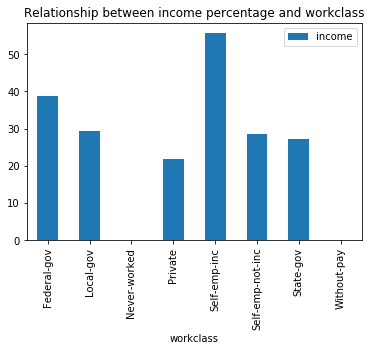

In [28]:
df_scenerio1 = df_filtered[["workclass", "income"]] #taking two columns in pd data frame



df_scenerio1["income"] = df_scenerio1["income"].apply(
    lambda x: 0 if x == "<=50K" else 1
)

# print(df_scenerio1)

df_new = df_scenerio1.groupby(["workclass"]).mean()

df_new["income"] = df_new["income"].apply(
    lambda x: x*100
)

df_new = df_new.reset_index()   #using reset can ungroup 
print(df_new)

 
ax = df_new.plot.bar(x="workclass", y="income", rot=90)



plt.title("Relationship between income percentage and workclass")    
plt.show()

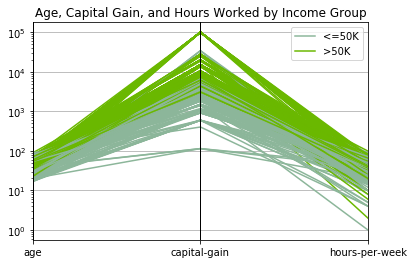

In [24]:
# Scenario 2:
# Check whether age, capital gain, and hours worked per week
# show different patterns for people earning <=50K vs >50K.

# Keep only the columns needed for this analysis.
df_scenario2 = df_filtered[
    ["age", "capital-gain", "hours-per-week", "income"]
].copy()

# Remove rows where capital gain is 0.

df_scenario2 = df_scenario2[
    df_scenario2["capital-gain"] != 0
]

# Randomly select 1000 rows so the graph does not become too crowded.
sample_df = df_scenario2.sample(1000)


pd.plotting.parallel_coordinates(
    sample_df,
    class_column="income",
    cols=["age", "capital-gain", "hours-per-week"]
)

# Use a logarithmic scale because capital-gain values
# have a very large range.
plt.yscale("log")

# Add a title.
plt.title("Age, Capital Gain, and Hours Worked by Income Group")

# Display the graph.
plt.show()

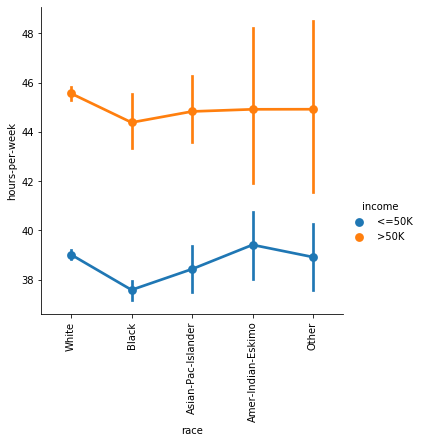

In [25]:
# Scenario 3: race, hours per week, income

import seaborn as sns

df_scenario3 = df_filtered[
    ["race", "hours-per-week", "income"]
].copy()

sns.catplot(
    data=df_scenario3,
    x="race",
    y="hours-per-week",
    hue="income",
    kind="point"
)

plt.xticks(rotation=90)
plt.show()

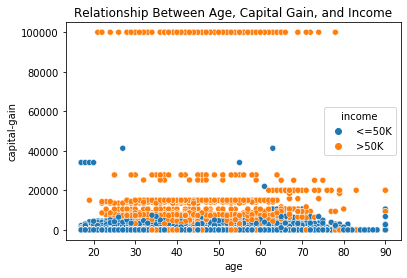

In [26]:
# Scenario 4:
# Examine the relationship between age and capital gain
# for people in the two different income groups.

import seaborn as sns
import matplotlib.pyplot as plt


df_scenario4 = df_filtered[
    ["age", "capital-gain", "income"]
].copy()

# Create a scatter plot
sns.scatterplot(
    data=df_scenario4,
    x="age",
    y="capital-gain",
    hue="income"
)


plt.title("Relationship Between Age, Capital Gain, and Income")

plt.show()

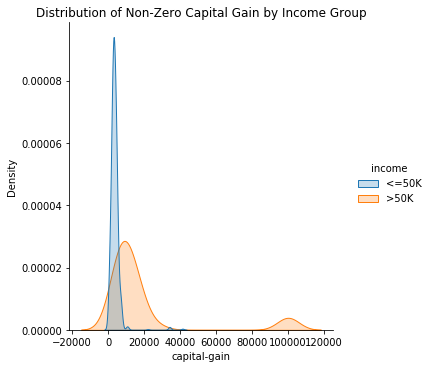

In [27]:
# Scenario 5:
# Compare the distribution of non-zero capital gain
# between people earning <=50K and >50K.

import seaborn as sns
import matplotlib.pyplot as plt

# Create a separate dataframe
df_scenario5 = df_filtered[
    ["capital-gain", "income"]
].copy()

# Keep only rows where capital gain is greater than 0
df_scenario5 = df_scenario5[
    df_scenario5["capital-gain"] > 0
]

# Create KDE plot
sns.displot(
    data=df_scenario5,
    x="capital-gain",
    hue="income",
    kind="kde",
    fill=True
)

plt.title("Distribution of Non-Zero Capital Gain by Income Group")
plt.show()